In [1]:
import sys
from pathlib import Path

root_dir = Path().absolute()
# Strip ~/notebooks/ccfraud from PYTHON_PATH if notebook started in one of these subdirectories
if root_dir.parts[-1:] == ('notebooks',):
    root_dir = Path(*root_dir.parts[:-1])
    sys.path.append(str(root_dir))
if root_dir.parts[-1:] == ('titanic',):
    root_dir = Path(*root_dir.parts[:-1])
    sys.path.append(str(root_dir))
root_dir = str(root_dir) 

print(f"Root dir: {root_dir}")

# Set the environment variables from the file <root_dir>/.env
from mlfs import config
settings = config.HopsworksSettings(_env_file=f"{root_dir}/.env")

Root dir: /Users/igormedeiros/Workspaces/irgmedeiros/mlfs-book
HopsworksSettings initialized!


In [2]:
import xgboost as xgb
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import seaborn as sns
from matplotlib import pyplot
import os
import pandas as pd
import hopsworks
import joblib

In [3]:
project = hopsworks.login()
fs = project.get_feature_store()

2026-07-07 22:05:43,451 INFO: Initializing external client


2026-07-07 22:05:43,452 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443


2026-07-07 22:05:44,843 INFO: Python Engine initialized.



Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/36986


In [4]:
# The feature view is the input set of features for your model. The features can come from different feature groups.    
# You can select features from different feature groups and join them together to create a feature view

from hopsworks.hsfs.builtin_transformations import label_encoder

titanic_fg = fs.get_feature_group(name="titanic", version=1)
selected_features = titanic_fg.select_features()

feature_view = fs.get_or_create_feature_view(name="titanic",
                                             version=1,
                                             description="Read from Titanic Passengers Dataset",
                                             labels=["survived"],
                                             transformation_functions = [
                                                 label_encoder("sex" ),
                                                 label_encoder("embarked")
                                             ],
                                             query=selected_features)

2026-07-07 22:05:46,380 INFO: Using ['sex', 'age', 'pclass', 'fare', 'parch', 'sibsp', 'embarked', 'survived'] from feature group `titanic` as features for the query. To include primary key and event time use `select_all`.


In [5]:
# You can read training data, randomly split into train/test sets of features (X) and labels (y)
X_train, X_test, y_train, y_test = feature_view.train_test_split(0.2)

X_train

2026-07-07 22:05:55,311 INFO: Computing insert statistics


Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (2.11s) 


2026-07-07 22:05:55,957 INFO: Computing insert statistics


2026-07-07 22:05:55,968 INFO: Computing insert statistics


2026-07-07 22:05:57,025 WARNING: VersionWarning: Incremented version to `2`.



,age,pclass,fare,parch,sibsp,label_encoder_embarked_,label_encoder_sex_
0,70.254635,3,51.84791,1,1,0,1
1,22.000000,3,7.25000,0,1,2,1
2,38.000000,1,71.28330,0,1,0,0
3,26.000000,3,7.92500,0,0,2,0
4,35.000000,1,53.10000,0,1,2,0
...,...,...,...,...,...,...,...
886,39.000000,3,29.12500,5,0,1,0
887,27.000000,2,13.00000,0,0,2,1
888,19.000000,1,30.00000,0,0,2,0
889,29.699118,3,23.45000,2,1,2,0


In [6]:
# Train our model with XGBoost Classifier
model = xgb.XGBClassifier()
model.fit(X_train, y_train.values.ravel())

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [7]:
# Evaluate model performance using the features from the test set (X_test)
y_pred = model.predict(X_test)
y_pred

array([0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0,
       1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 1])

In [8]:
# Compare predictions (y_pred) with the labels in the test set (y_test)
metrics = classification_report(y_test, y_pred, output_dict=True)
results = confusion_matrix(y_test, y_pred)
metrics

{'0': {'precision': 0.8017241379310345,
  'recall': 0.8773584905660378,
  'f1-score': 0.8378378378378378,
  'support': 106.0},
 '1': {'precision': 0.7936507936507936,
  'recall': 0.684931506849315,
  'f1-score': 0.7352941176470589,
  'support': 73.0},
 'accuracy': 0.7988826815642458,
 'macro avg': {'precision': 0.7976874657909141,
  'recall': 0.7811449987076764,
  'f1-score': 0.7865659777424483,
  'support': 179.0},
 'weighted avg': {'precision': 0.7984316567441206,
  'recall': 0.7988826815642458,
  'f1-score': 0.7960183318382464,
  'support': 179.0}}

2026-07-07 22:05:57,583 WARNING: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown



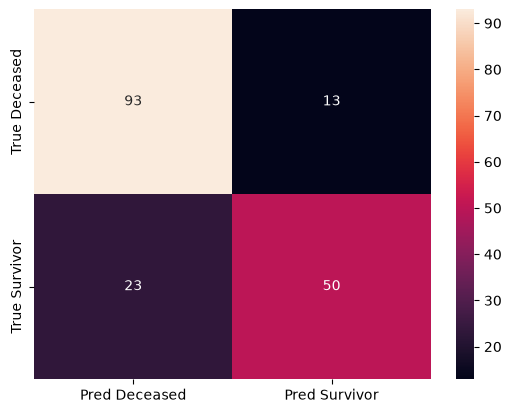

In [9]:
# Create the confusion matrix as a figure, we will later store it as a PNG image file
df_cm = pd.DataFrame(results, ['True Deceased', 'True Survivor'],
                     ['Pred Deceased', 'Pred Survivor'])
cm = sns.heatmap(df_cm, annot=True)
fig = cm.get_figure()

fig.show()

In [10]:
# We will now upload our model to the Hopsworks Model Registry. First get an object for the model registry.
mr = project.get_model_registry()

# The contents of the 'iris_model' directory will be saved to the model registry. Create the dir, first.
model_dir="titanic_model"
if os.path.isdir(model_dir) == False:
    os.mkdir(model_dir)
images_dir = model_dir + "/images"
if os.path.isdir(images_dir) == False:
    os.mkdir(images_dir)

# Save both our model and the confusion matrix to 'model_dir', whose contents will be uploaded to the model registry
# Saving the XGBoost classifier object using joblib
joblib.dump(model, model_dir + "/titanic_model.pkl")
fig.savefig(images_dir + "/confusion_matrix.png")    

# Create an entry in the model registry that includes the model's name, desc, metrics
titanic_model = mr.python.create_model(
    name="titanic", 
    metrics={"accuracy" : metrics['accuracy'], 
             'f1 score' : metrics['weighted avg']['f1-score']},
    feature_view=feature_view,
    description="Titanic Survivor Predictor"
)

# Upload the model to the model registry, including all files in 'model_dir'
titanic_model.save(model_dir)

  0%|          | 0/6 [00:00<?, ?it/s]

Creating model folder:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model folder:  17%|█▋        | 1/6 [00:01<00:05,  1.18s/it]

Uploading model files:  17%|█▋        | 1/6 [00:01<00:05,  1.18s/it]

Uploading model files (0 dirs, 0 files):  17%|█▋        | 1/6 [00:01<00:05,  1.18s/it]

...

Waiting for model registration:  83%|████████▎ | 5/6 [00:11<00:02,  2.91s/it]

Model export complete:  83%|████████▎ | 5/6 [00:11<00:02,  2.91s/it]         

Model export complete: 100%|██████████| 6/6 [00:11<00:00,  1.95s/it]

Model created, explore it at https://eu-west.cloud.hopsworks.ai:443/p/36986/models/titanic/1


Model(name: 'titanic', version: 1)